In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

# Task 1: Data Prep & Baseline


In [3]:
# =========================================================
# Task 2 — Load the Palmer Penguins dataset and drop missing values
# =========================================================
penguins = sns.load_dataset("penguins").dropna()

# =========================================================
# Task 3 — Brief exploration:
# How many samples and features?
# What are the three species and their distribution?
# Which columns are categorical vs. numerical?
# =========================================================
print("Dataset shape (rows, columns):", penguins.shape)
print("\nColumn names:")
print(penguins.columns.tolist())

print("\nFirst 5 rows:")
print(penguins.head())

print("\nSpecies distribution:")
print(penguins["species"].value_counts())

categorical_cols = penguins.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = penguins.select_dtypes(include=["number"]).columns.tolist()

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

# =========================================================
# Task 4 — Encode the target variable (species) with LabelEncoder
# =========================================================
label_encoder = LabelEncoder()
penguins["species_encoded"] = label_encoder.fit_transform(penguins["species"])

print("\nEncoded species classes:")
for original_class, encoded_class in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{original_class} -> {encoded_class}")

# =========================================================
# Task 5 — Prepare features:
# Drop original target columns from X
# Keep encoded target as y
# Encode categorical input features with pd.get_dummies(drop_first=True)
# =========================================================
X = penguins.drop(columns=["species", "species_encoded"])
y = penguins["species_encoded"]

X = pd.get_dummies(X, drop_first=True)

print("\nFeature matrix shape after encoding:", X.shape)
print("\nEncoded feature columns:")
print(X.columns.tolist())

# =========================================================
# Task 6 — Split into training and test sets
# 80/20 split, stratify=y, random_state=42
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# =========================================================
# Task 7 — Scale the features using StandardScaler
# Fit on training data only, then transform both train and test
# =========================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# Task 8 — Fit a LogisticRegression model
# max_iter=10000, multi_class='multinomial'
# =========================================================
log_reg = LogisticRegression(
    max_iter=10000,
)

log_reg.fit(X_train_scaled, y_train)

# =========================================================
# Task 9 — Make predictions on the test set
# =========================================================
y_pred = log_reg.predict(X_test_scaled)

# =========================================================
# Task 10 — Report evaluation metrics:
# accuracy, precision, recall, F1 score
# Print full classification_report
# =========================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("\nModel Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Dataset shape (rows, columns): (333, 7)

Column names:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

First 5 rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  

Species distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Categorical columns:
['species', 'island', 'sex']

Numerical columns:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',

C:\Users\pc\AppData\Local\Temp\ipykernel_19776\2279556688.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = penguins.select_dtypes(include=["object", "category"]).columns.tolist()


### step 8
The results show that Gentoo is the easiest species to classify because it achieved perfect precision, recall, and F1-score. This means that every Gentoo sample in the test set was correctly identified by the model. A likely reason is that Gentoo penguins have more distinctive physical characteristics compared with the other species, especially higher body mass and longer flipper length, which make them easier to separate in the feature space. 

The hardest species to classify is Chinstrap because its precision is slightly lower than the others, even though recall is perfect. This means the model correctly found all Chinstrap samples, but a few penguins from another species were predicted as Chinstrap. This may happen because Chinstrap and Adelie share similar body measurements in some cases, particularly bill-related features, so their boundaries are less clearly separated. Adelie also performs very well overall, but one sample was misclassified, which suggests a small overlap with Chinstrap in some observations.


# Task 2: Algorithm Comparison


In [4]:
# =========================================================
# Task — Define models
# =========================================================
models = {
    "GaussianNB": GaussianNB(),
    "SVC Linear": SVC(kernel="linear", probability=True),
    "SVC RBF": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# =========================================================
# Task — Train each model and collect evaluation metrics
# =========================================================
results = []

for name, model in models.items():
    
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    # Save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# =========================================================
# Task — Create comparison DataFrame
# =========================================================
comparison_df = pd.DataFrame(results)

# Sort by F1 descending
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

# Reset index
comparison_df = comparison_df.reset_index(drop=True)

# =========================================================
# Task — Display comparison table
# =========================================================
print(comparison_df)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  1.000000   1.000000  1.000000  1.000000
1     SVC Linear  0.985075   0.986070  0.985075  0.985201
2        SVC RBF  0.985075   0.986070  0.985075  0.985201
3  Decision Tree  0.955224   0.957214  0.955224  0.955212
4     GaussianNB  0.776119   0.851175  0.776119  0.760229


### step 4

Random Forest gave the best result because it reached perfect scores in all metrics. This means the model classified all penguin species correctly in the test set. A possible reason is that Random Forest combines many decision trees and can capture more complex relationships between features, so it works very well when the classes are clearly separated.

Both SVC Linear and SVC RBF also performed very strongly and gave almost the same result. This shows that the penguin species are already well separated in the feature space, so even a linear boundary is enough in most cases. It is a little interesting that the RBF version did not improve much, because usually it handles more complex patterns, but here the dataset seems simple enough that both kernels work similarly.

Decision Tree performed slightly lower than Random Forest. This is expected because a single tree can depend too much on specific training patterns and may not generalize as well as an ensemble model.

Gaussian Naive Bayes had the lowest performance. This is probably because it assumes that all features are independent from each other, but in this dataset some measurements such as body mass, flipper length, and bill size are related, so that assumption does not fully match the real data.


# Task 3: Confusion Matrices & ROC Curves


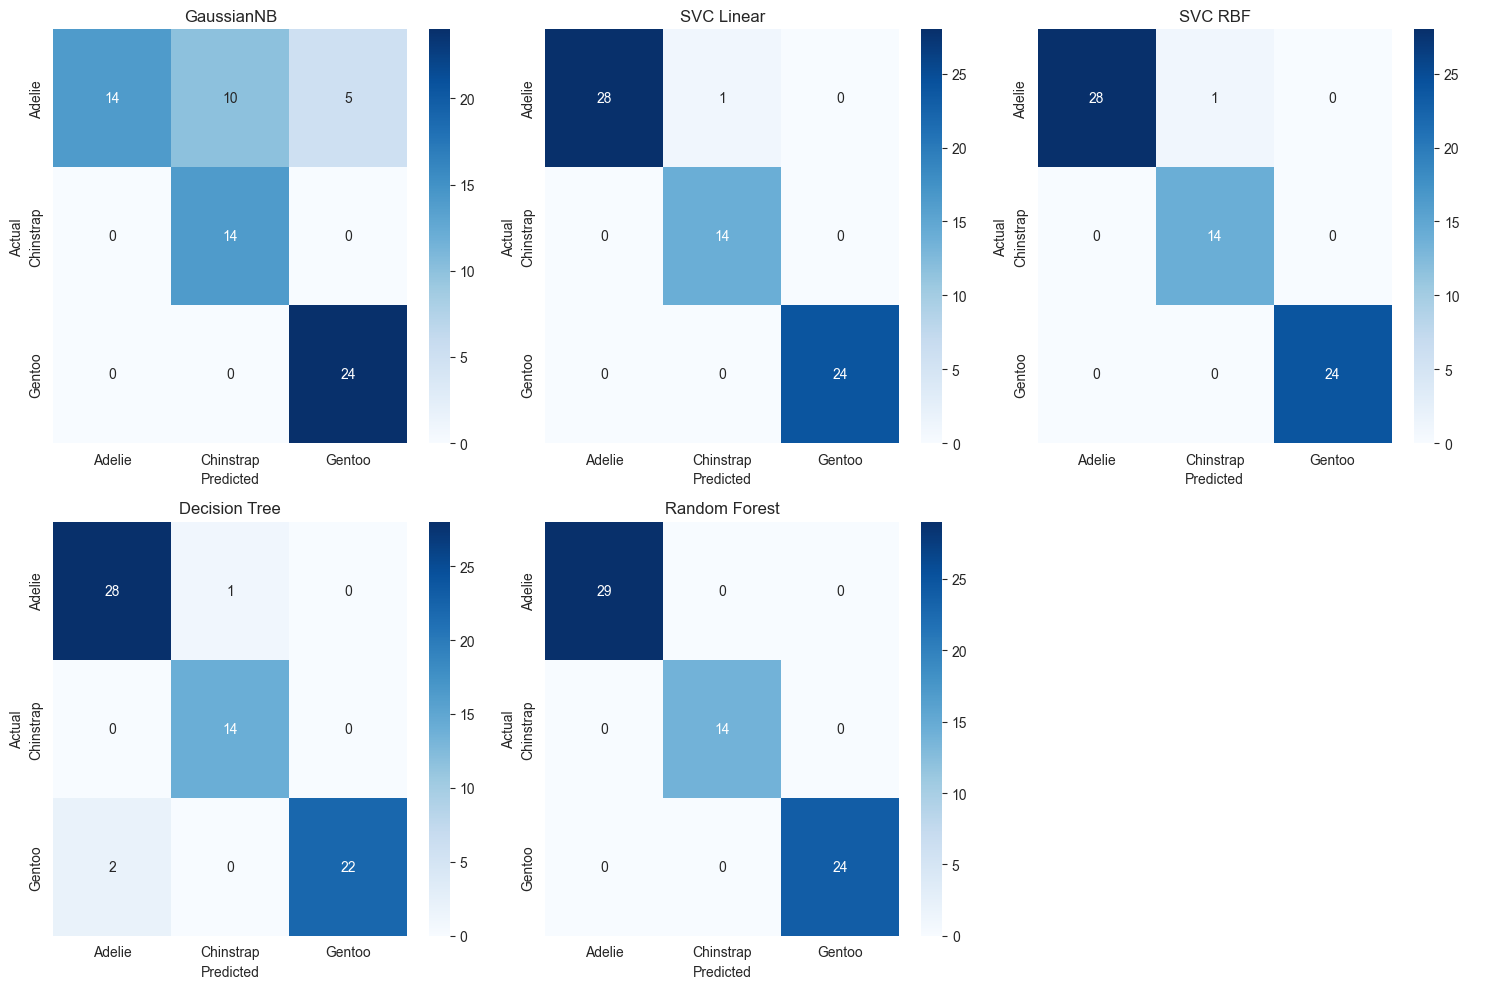

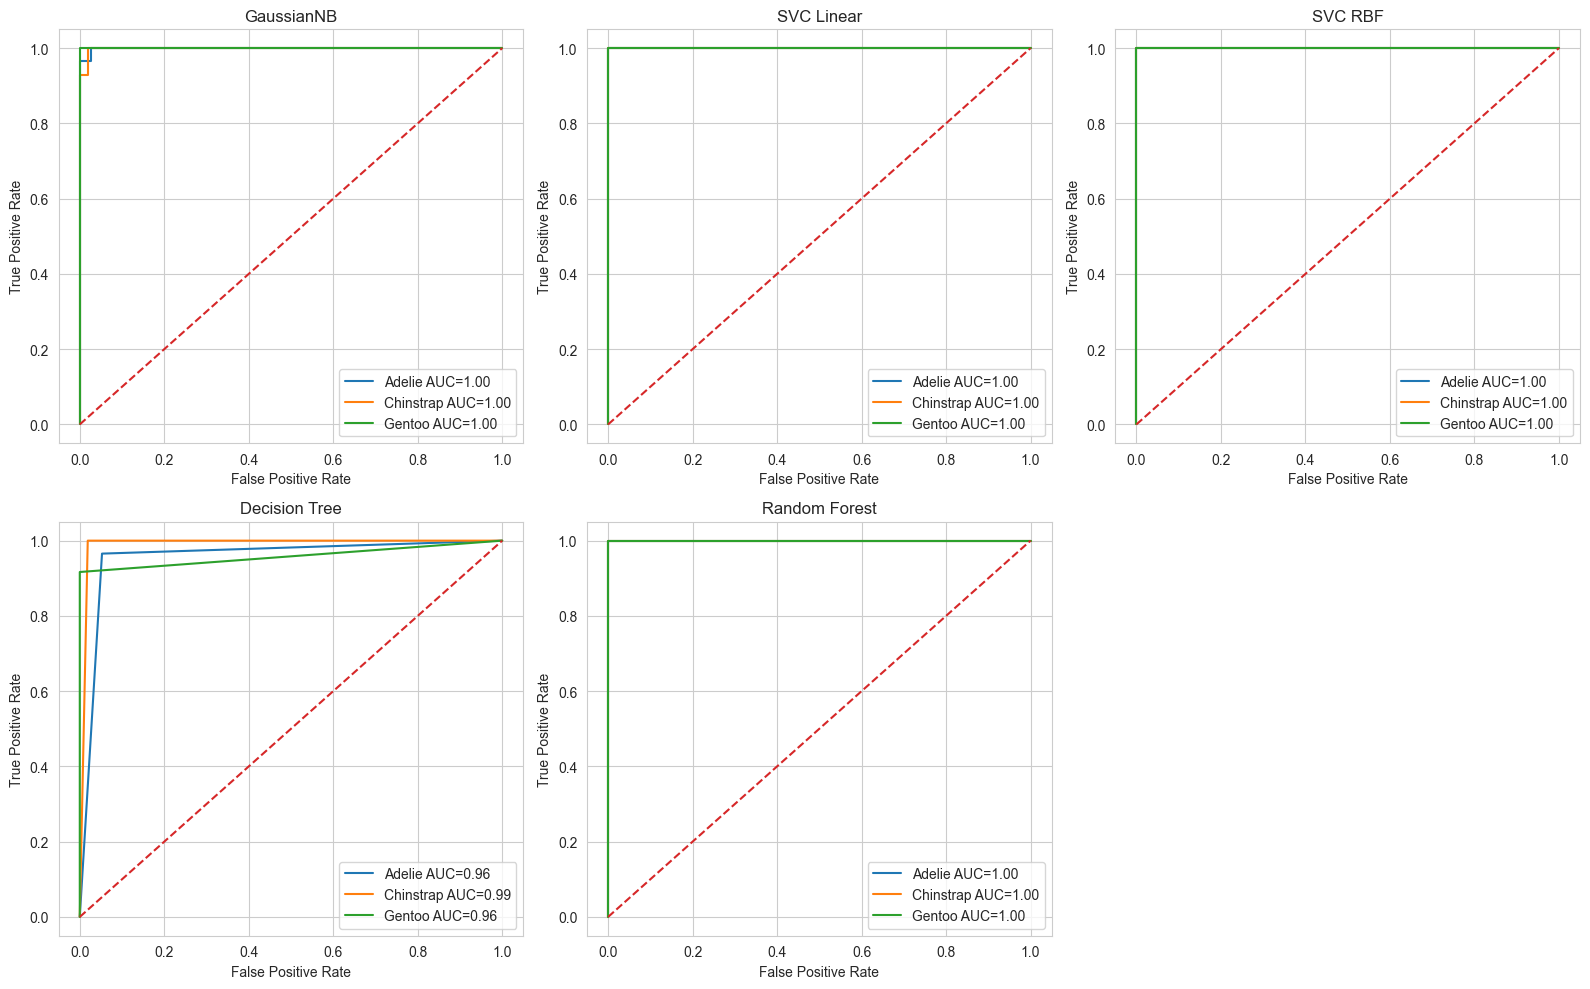

In [7]:
from sklearn.preprocessing import label_binarize
# =========================================================
# Task — Define models again
# =========================================================
models = {
    "GaussianNB": GaussianNB(),
    "SVC Linear": SVC(kernel="linear", probability=True),
    "SVC RBF": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# =========================================================
# Task — Train models and store predictions
# =========================================================
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

# =========================================================
# Task — Plot confusion matrices in grid
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

# Hide empty subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# Task — Prepare multiclass ROC data
# =========================================================
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# =========================================================
# Task — Plot ROC curves for each model
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    
    y_score = model.predict_proba(X_test_scaled)
    
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        
        axes[idx].plot(
            fpr,
            tpr,
            label=f"{label_encoder.classes_[i]} AUC={roc_auc:.2f}"
        )
    
    axes[idx].plot([0, 1], [0, 1], linestyle="--")
    
    axes[idx].set_title(name)
    axes[idx].set_xlabel("False Positive Rate")
    axes[idx].set_ylabel("True Positive Rate")
    axes[idx].legend()

# Hide empty subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

The Random Forest model provides the best balance between precision and recall across all three penguin species. Its confusion matrix shows that all predictions fall on the diagonal, meaning every test sample was classified correctly and no species was confused with another one. This indicates perfect precision and recall on this test set. The SVC Linear and SVC RBF models also perform very strongly, but each makes one small mistake where an Adelie penguin is predicted as Chinstrap, so their performance is slightly lower than Random Forest.

The hardest species pair to distinguish is Adelie and Chinstrap. This pattern appears in the models that make errors, because most of the mistakes happen between these two species. A likely reason is that Adelie and Chinstrap have more similar physical measurements, especially in bill dimensions and body size, while Gentoo penguins are generally larger and therefore easier to separate. Gentoo shows the clearest boundaries in the feature space, which explains why it is classified almost perfectly by nearly all models.

Based on all results, Random Forest is the strongest final model for this dataset. It reaches perfect evaluation scores and also shows AUC values very close to 1.00 for all classes, meaning it separates the species extremely well. Its ensemble structure makes it more stable than a single Decision Tree and better able to capture feature interactions. Overall, Random Forest appears to be the most reliable choice for penguin species classification on this dataset.


# Task 4: Hyperparameter Exploration


In [8]:
# =========================================================
# Task — Import GridSearchCV
# =========================================================
from sklearn.model_selection import GridSearchCV

# =========================================================
# Task — Define hyperparameter grid for Random Forest
# =========================================================
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

# =========================================================
# Task — Initialize base Random Forest model
# =========================================================
rf = RandomForestClassifier(random_state=42)

# =========================================================
# Task — Run GridSearchCV with 5-fold CV
# scoring = weighted F1 for multiclass classification
# =========================================================
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

# =========================================================
# Task — Print best parameters and best CV score
# =========================================================
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

# =========================================================
# Task — Get best tuned model
# =========================================================
best_rf = grid_search.best_estimator_

# =========================================================
# Task — Predict on test set
# =========================================================
y_pred_tuned = best_rf.predict(X_test_scaled)

# =========================================================
# Task — Evaluate tuned model
# =========================================================
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average="weighted")
recall_tuned = recall_score(y_test, y_pred_tuned, average="weighted")
f1_tuned = f1_score(y_test, y_pred_tuned, average="weighted")

print("\nTuned Model Test Metrics:")
print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1 Score : {f1_tuned:.4f}")

# =========================================================
# Task — Compare default vs tuned model
# =========================================================
comparison = pd.DataFrame({
    "Model": ["Default Random Forest", "Tuned Random Forest"],
    "Accuracy": [1.0000, accuracy_tuned],
    "Precision": [1.0000, precision_tuned],
    "Recall": [1.0000, recall_tuned],
    "F1 Score": [1.0000, f1_tuned]
})

print("\nComparison Table:")
print(comparison)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation F1 Score:
0.9961656161968262

Tuned Model Test Metrics:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Comparison Table:
                   Model  Accuracy  Precision  Recall  F1 Score
0  Default Random Forest       1.0        1.0     1.0       1.0
1    Tuned Random Forest       1.0        1.0     1.0       1.0


The tuning process did not produce a visible improvement on the test set because the default Random Forest model had already achieved perfect performance before tuning. After GridSearchCV, the tuned model also reached 1.00 in all evaluation metrics, so in this case the improvement is not significant in terms of final test accuracy or F1 score. The best parameters still confirm that a relatively simple Random Forest configuration works very well for this dataset.

There is always some risk of overfitting during hyperparameter tuning because the model is repeatedly evaluated on the validation folds and may adapt to those specific splits. However, in this case the cross-validation F1 score is also very high and close to the final test performance, which suggests that the model remains stable rather than overfitting strongly.

Hyperparameter tuning is usually most impactful when the dataset is more complex, when model performance is not already near perfect, or when different parameter choices strongly affect the model behavior. In this dataset, the classes are already very clearly separated, so even the default model performs at the highest level, leaving little room for improvement.